## Handwritten digit classification 

In [3]:
# importing Liabraries 
import pandas as pd 
import numpy as np 
from tensorflow import keras  
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense,Flatten

In [4]:
# test-train split 

(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data() 

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
X_train.shape 

(60000, 28, 28)

In [10]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

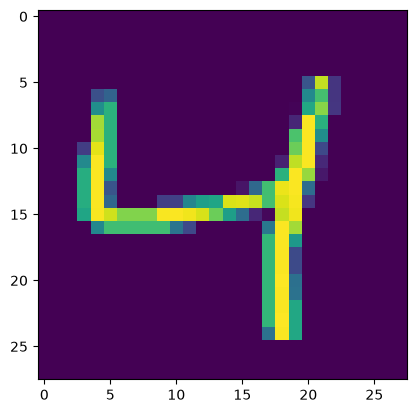

In [16]:
# importing matplotlib for visualization

import matplotlib.pyplot as plt 
plt.imshow(X_train[2])

In [17]:
# Rangin down values from 0-255 to 0-1 -> deviding by 255  

X_train = X_train / 255
X_test = X_test / 255

In [53]:
# buildin the mdoel 

model = Sequential() 

# Problem : we have 784 input in the format of 28 x 28 -> in order to do that we have to use Flatten Layer 

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax')) 

model.summary()

/Users/piyush/Repositories/Deep-Learning/codes/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
# compiling the model to congifgure the learning process by loss function , optimisers and metrics

model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [56]:
history = model.fit(X_train,y_train,epochs=25 , validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 768us/step - accuracy: 0.9979 - loss: 0.0066 - val_accuracy: 0.9762 - val_loss: 0.1665
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 773us/step - accuracy: 0.9974 - loss: 0.0087 - val_accuracy: 0.9768 - val_loss: 0.1441
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 753us/step - accuracy: 0.9971 - loss: 0.0095 - val_accuracy: 0.9744 - val_loss: 0.1659
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 778us/step - accuracy: 0.9980 - loss: 0.0061 - val_accuracy: 0.9747 - val_loss: 0.1754
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 771us/step - accuracy: 0.9976 - loss: 0.0074 - val_accuracy: 0.9780 - val_loss: 0.1689
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 752us/step - accuracy: 0.9974 - loss: 0.0083 - val_accuracy: 0.9767 - val_loss: 0.1802
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step - accuracy: 0.9980 - loss: 0.0061 - val_accuracy: 0.9772 - val_loss: 0.1713
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step - accuracy: 0.9973 -

In [57]:
# making predictions now 

y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step


In [58]:
# we need to find the maximum value in every array to get which number is ont the data set 

y_pred = y_prob.argmax(axis=1)

In [59]:
from sklearn.metrics import accuracy_score


In [60]:
accuracy_score(y_test,y_pred)

0.978

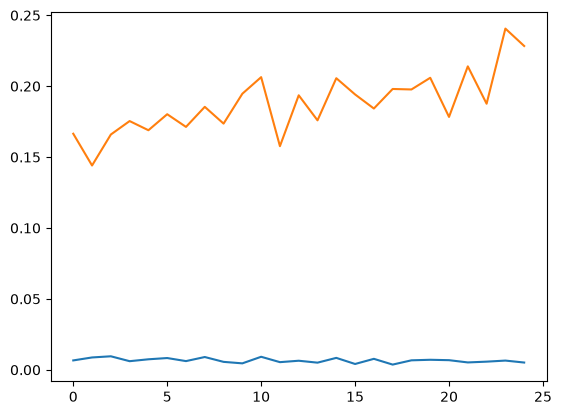

In [64]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

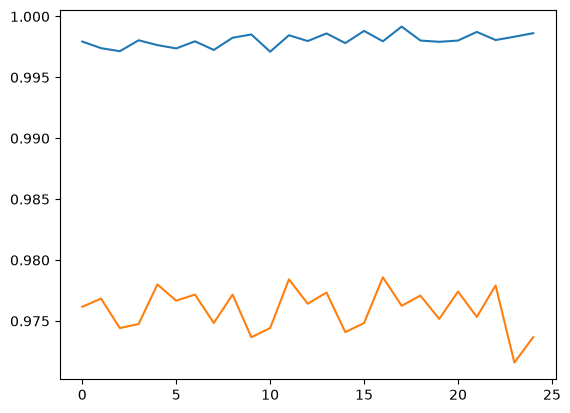

In [61]:
# graph for visualization 

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

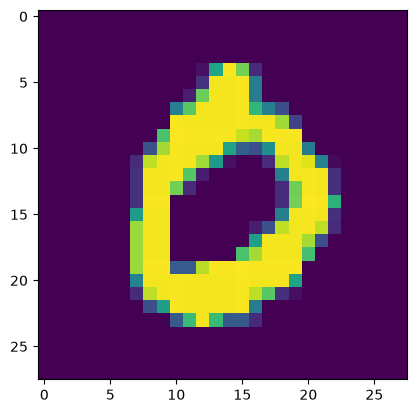

In [71]:
plt.imshow(X_test[3])

In [72]:
model.predict(X_test[2].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


array([1])